User Topic --> Create explanantion --> Create summary

In [1]:
import os 
from dotenv import load_dotenv
from typing import TypedDict


from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END

1. Load API keys


In [2]:
load_dotenv()

True

2. Create LLM

In [3]:

model = init_chat_model(
    "openai/gpt-oss-20b",
    model_provider="openrouter",
    temperature=0
)


3. Create state

In [4]:
class State(TypedDict):
    topic: str
    explanation:str
    summary: str

4. Create Explanation Node

In [9]:
def generate_explanation(state):

    prompt = f"Explain the topic '{state['topic']}' in simple terms."

    response = model.invoke(prompt)

    return {"explanation": response.content}

5. Create summary node

In [10]:
def generate_summary(state):

    prompt = f"Summarize the'{state['explanation']}' in 3 sentences."

    response = model.invoke(prompt)

    return {"summary": response.content}

5. Create Graph

In [11]:
builder = StateGraph(State)

6. Add Node

In [12]:
builder.add_node("generate_explanation", generate_explanation)
builder.add_node("generate_summary", generate_summary)

7. Add edges

In [13]:
builder.add_edge(START, "generate_explanation")
builder.add_edge("generate_explanation", "generate_summary")
builder.add_edge("generate_summary", END)

8. Compile

In [14]:
graph = builder.compile()

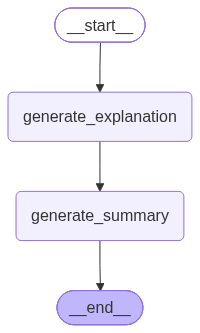

In [19]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

9. Invoke

In [15]:
result = graph.invoke({"topic": "Langgraph"})

10. Print Response

In [ ]:
print(result["topic"])


Langgraph
## What is LangGraph?

**LangGraph** is a tool that lets you build *chat‑bot‑style* or *AI‑powered* applications by putting together a series of “steps” (nodes) that talk to each other, just like a flowchart or a graph.  
Think of it as a **visual recipe** for an AI program, where each step can:

* Ask a question
* Call an external API
* Store data
* Decide what to do next

The “graph” part means you can connect these steps in any shape you want—linear, branching, loops, or even complex decision trees—so the AI can handle many different user paths.

---

## Why use LangGraph?

| Problem | How LangGraph Helps |
|---------|---------------------|
| **Complex logic** – A single LLM prompt can’t handle all the rules and data you need. | Break the logic into small, reusable nodes that can be combined in many ways. |
| **State management** – Keeping track of user context, past messages, or external data is hard. | LangGraph automatically stores and passes “state” between nodes. |
| 

In [17]:
print(result["explanation"])


## What is LangGraph?

**LangGraph** is a tool that lets you build *chat‑bot‑style* or *AI‑powered* applications by putting together a series of “steps” (nodes) that talk to each other, just like a flowchart or a graph.  
Think of it as a **visual recipe** for an AI program, where each step can:

* Ask a question
* Call an external API
* Store data
* Decide what to do next

The “graph” part means you can connect these steps in any shape you want—linear, branching, loops, or even complex decision trees—so the AI can handle many different user paths.

---

## Why use LangGraph?

| Problem | How LangGraph Helps |
|---------|---------------------|
| **Complex logic** – A single LLM prompt can’t handle all the rules and data you need. | Break the logic into small, reusable nodes that can be combined in many ways. |
| **State management** – Keeping track of user context, past messages, or external data is hard. | LangGraph automatically stores and passes “state” between nodes. |
| **Reusabil

In [18]:
print(result["summary"])

LangGraph is a framework that lets you build AI‑powered applications by wiring together modular “nodes”—each a small piece of code or prompt that can ask questions, call APIs, store data, or make decisions—into a flexible graph that can be linear, branching, or looped. It automatically manages state, passes data between nodes, and provides a visual workflow that makes debugging, reusability, and integration with external services straightforward. This approach is ideal for complex chatbots, data‑driven assistants, decision engines, and rapid prototyping, turning a monolithic prompt into a clean, maintainable, and extensible AI workflow.
